<a href="https://colab.research.google.com/github/shaizawaseem10505/2nd-repo/blob/main/Titanic_Project.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#Import Data

In [15]:
import pandas as pd
import matplotlib.pyplot as plt

df=pd.read_csv('train.csv')


#Data Inspection

In [16]:
df.head(5)


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [17]:
df.tail(5)

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
886,887,0,2,"Montvila, Rev. Juozas",male,27.0,0,0,211536,13.00,NaN,S
887,888,1,1,"Graham, Miss. Margaret Edith",female,19.0,0,0,112053,30.00,B42,S
888,889,0,3,"Johnston, Miss. Catherine Helen ""Carrie""",female,NaN,1,2,W./C. 6607,23.45,NaN,S
889,890,1,1,"Behr, Mr. Karl Howell",male,26.0,0,0,111369,30.00,C148,C
890,891,0,3,"Dooley, Mr. Patrick",male,32.0,0,0,370376,7.75,NaN,Q


In [18]:
print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB
None


In [19]:
df.describe().round(2)

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.00,891.00,891.00,714.00,891.00,891.00,891.00
mean,446.00,0.38,2.31,29.70,0.52,0.38,32.20
std,257.35,0.49,0.84,14.53,1.10,0.81,49.69
min,1.00,0.00,1.00,0.42,0.00,0.00,0.00
25%,223.50,0.00,2.00,20.12,0.00,0.00,7.91
50%,446.00,0.00,3.00,28.00,0.00,0.00,14.45
75%,668.50,1.00,3.00,38.00,1.00,0.00,31.00
max,891.00,1.00,3.00,80.00,8.00,6.00,512.33


In [20]:
df.shape

(891, 12)

# Checking missing values

In [21]:
df.isnull().sum()

,0
PassengerId,0
Survived,0
Pclass,0
Name,0
Sex,0
Age,177
SibSp,0
Parch,0
Ticket,0
Fare,0


In [22]:
df.head(2)

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C


#Filling missing values

In [23]:
df['Age']=df['Age'].fillna(df['Age'].median())
df['Age']

,Age
0,22.0
1,38.0
2,26.0
3,35.0
4,35.0
...,...
886,27.0
887,19.0
888,28.0
889,26.0


In [24]:
df['Embarked'].fillna(df['Embarked'].mode()[0],inplace=True)
df['Embarked']

/tmp/ipykernel_409/1137805032.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['Embarked'].fillna(df['Embarked'].mode()[0],inplace=True)


,Embarked
0,S
1,C
2,S
3,S
4,S
...,...
886,S
887,S
888,S
889,C


In [25]:
df.drop('Cabin',axis=1, inplace=True)

In [26]:
df.isnull().sum()

,0
PassengerId,0
Survived,0
Pclass,0
Name,0
Sex,0
Age,0
SibSp,0
Parch,0
Ticket,0
Fare,0


#Classifying Categories wise

In [27]:
numerical_cols=df[["Age","SibSp","Parch","Fare"]]
numerical_cols

,Age,SibSp,Parch,Fare
0,22.0,1,0,7.2500
1,38.0,1,0,71.2833
2,26.0,0,0,7.9250
3,35.0,1,0,53.1000
4,35.0,0,0,8.0500
...,...,...,...,...
886,27.0,0,0,13.0000
887,19.0,0,0,30.0000
888,28.0,1,2,23.4500
889,26.0,0,0,30.0000


In [28]:
categorical_col=df.select_dtypes(include=object).columns
categorical_col

Index(['Name', 'Sex', 'Ticket', 'Embarked'], dtype='object')

# Exploring the numerical columns

In [29]:
import seaborn as sns

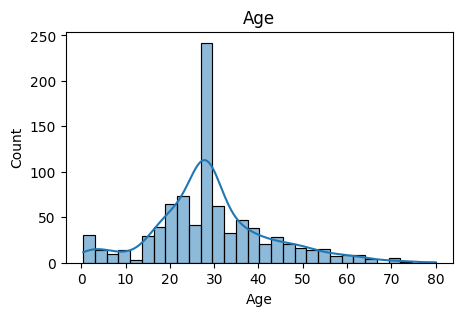

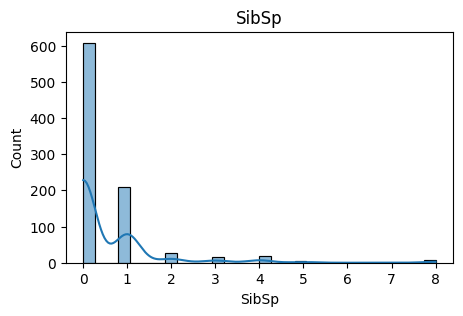

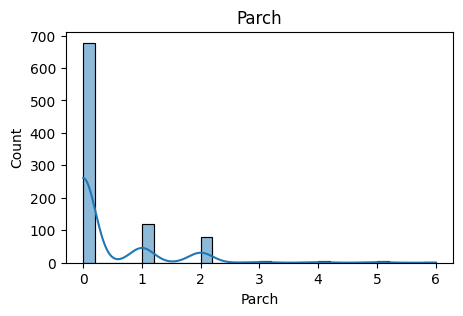

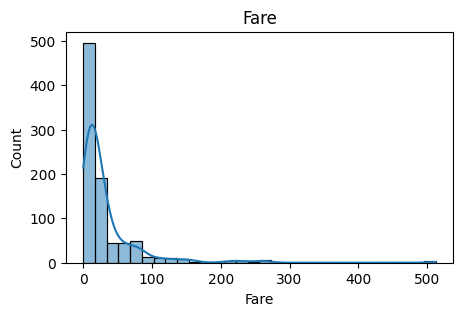

In [30]:
for col in numerical_cols:
  plt.figure(figsize=(5,3))
  sns.histplot(data=df, x=col, bins=30,kde=True)

  plt.title(col)
  plt.show()

#Insights:
Age follows a fairly normal distribution with most passengers between 20-40 years. SibSp, Parch ,Fare are all right skewed meaning most passengers had few siblings ,few parents and paid lower fare,while a small number of outliers had much higher values.

In [31]:
df['Fare'].max()

512.3292

In [32]:
df['Fare'].describe()

,Fare
count,891.000000
mean,32.204208
std,49.693429
min,0.000000
25%,7.910400
50%,14.454200
75%,31.000000
max,512.329200


In [33]:
df["Fare"].skew()

np.float64(4.787316519674893)

In [34]:
df['Age'].skew()

np.float64(0.5102446555756495)

In [35]:
df['Parch'].skew()

np.float64(2.7491170471010933)

In [36]:
df['SibSp'].skew()

np.float64(3.6953517271630565)

#Skewness Values
Fare has the highest skew (4.79), followed by SibSp (3.70) and Parch (2.75), confirming these are heavily right-skewed. Age has a skew of only 0.39, meaning it's close to a normal distribution.

# Exploring The Categorical Columns

In [37]:
categorical_col=df[['Sex','Embarked','Pclass','Survived']]
categorical_col

,Sex,Embarked,Pclass,Survived
0,male,S,3,0
1,female,C,1,1
2,female,S,3,1
3,female,S,1,1
4,male,S,3,0
...,...,...,...,...
886,male,S,2,0
887,female,S,1,1
888,female,S,3,0
889,male,C,1,1


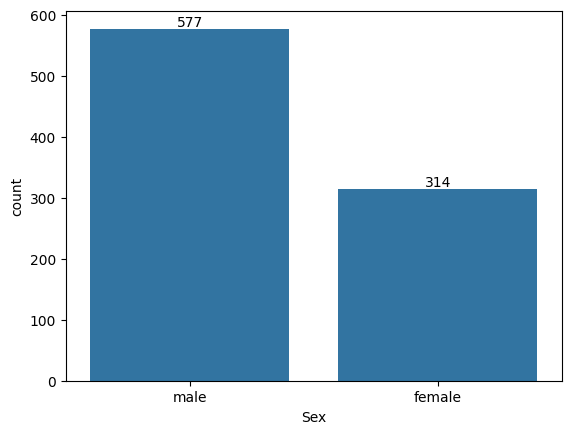

In [38]:
ax=sns.countplot(data=df,x='Sex')
for cont in ax.containers:                #show exact count on the top of bars
  ax.bar_label(cont)

#
There were more male passengers than female passengers on board.



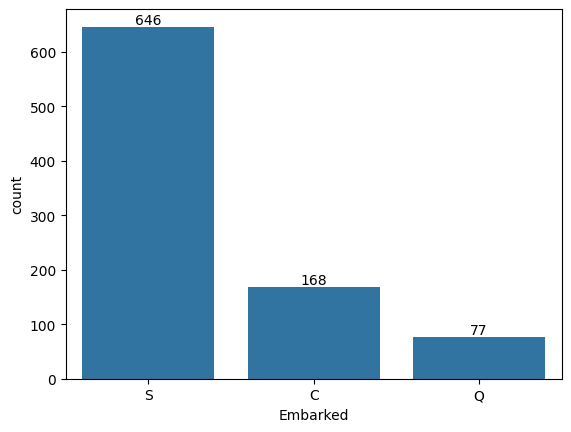

In [39]:
am=sns.countplot(data=df,x='Embarked')
for cont in am.containers:
  am.bar_label(cont)

#
The majority of passengers boarded from Southampton (S), followed by Cherbourg (C) and Queenstown (Q).

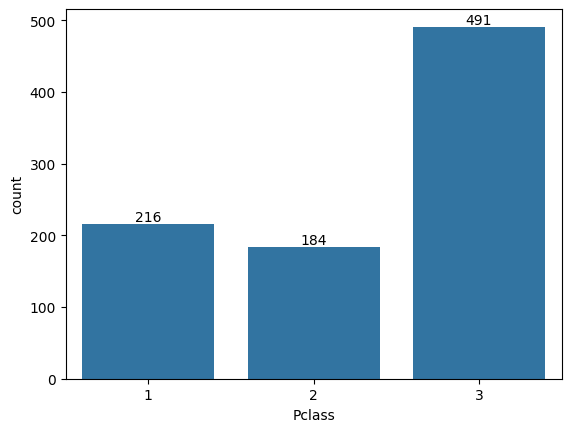

In [40]:
az=sns.countplot(data=df,x='Pclass')
for container in az.containers:
  az.bar_label(container)
plt.show()

#
Most passengers were traveling in 3rd class, followed by 1st and 2nd class.

#Survived vs Sex

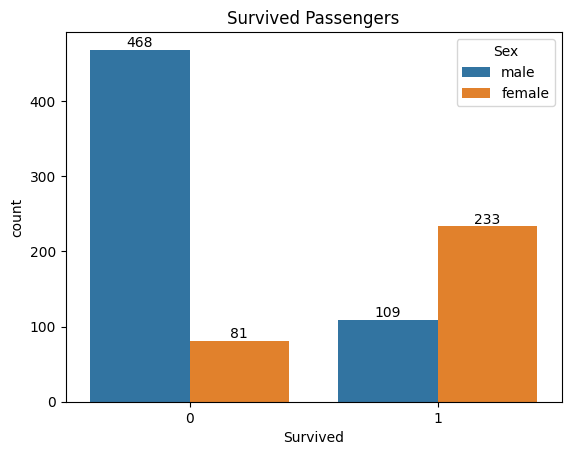

In [41]:
ab=sns.countplot(data=df,x='Survived',hue='Sex')
for container in ab.containers:
  ab.bar_label(container)
plt.title("Survived Passengers")
plt.show()

#


Female passengers had a noticeably higher survival count and rate compared to male passengers, supporting the "women first" evacuation policy.

In [42]:
df['Pclass'].unique()

array([3, 1, 2])

In [43]:
df["Survived"].unique()

array([0, 1])

#Corelation

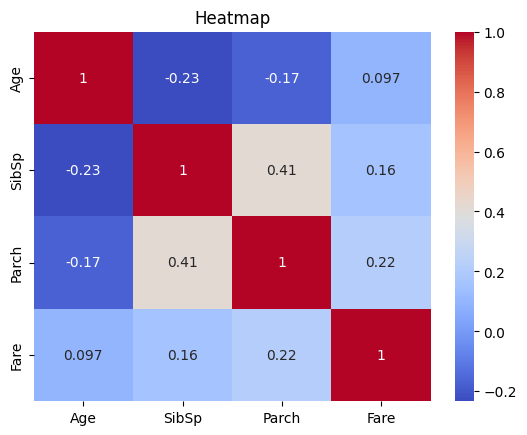

In [44]:
numerical_cols=df[["Age","SibSp","Parch","Fare"]]
corr=numerical_cols.corr()
sns.heatmap(corr,annot=True,cmap='coolwarm')
plt.title("Heatmap")
plt.show()

#Correlation Heatmap Interpretation
The correlation heatmap shows the relationship between the numerical features in the dataset.<br>
**SibSp and Parch** have the highest positive correlation (0.41), indicating a moderate relationship.<br>
**Age** has a weak negative correlation with SibSp (-0.23) and Parch (-0.17).
<br>

**Fare **has a weak positive correlation with Age (0.097), SibSp (0.16), and Parch (0.22).<br>

Most correlation values are close to 0, which means the relationships between the variables are weak.<br>
No feature pair has a strong correlation (greater than 0.7).

#Relation with Survival

#Survived vs Pclass

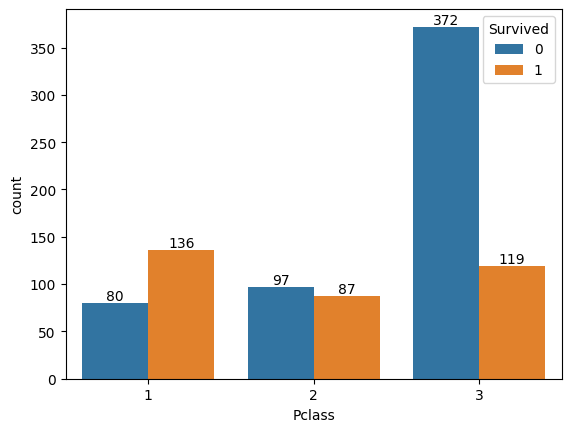

In [45]:
aj=sns.countplot(data=df,x='Pclass' ,hue='Survived')
for cont in aj.containers:
  aj.bar_label(cont)

#
1st class passengers had the highest survival rate, while 2nd & 3rd class passengers had the lowest, suggesting that class/wealth played a major role in survival chances.

#Survived vs Sex

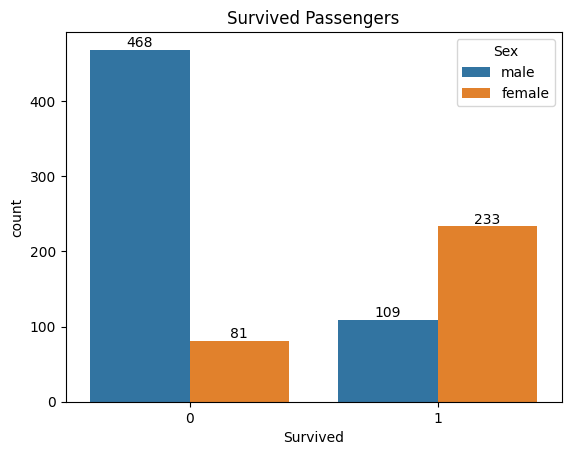

In [46]:
ab=sns.countplot(data=df,x='Survived',hue='Sex')
for container in ab.containers:
  ab.bar_label(container)
plt.title("Survived Passengers")
plt.show()

#


Female passengers had a noticeably higher survival count and rate compared to male passengers, supporting the "women first" evacuation policy.

#Survived vs Age

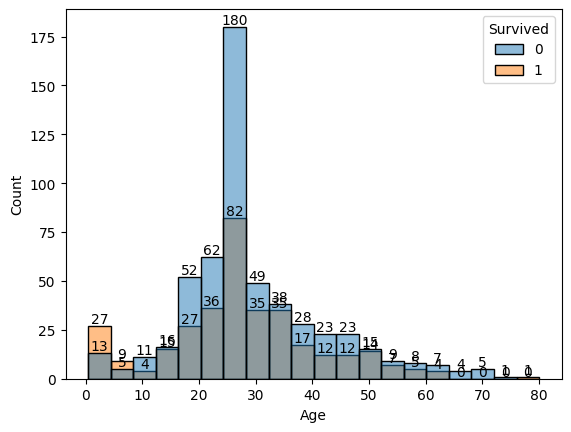

In [47]:
aj=sns.histplot(data=df,x='Age' ,hue='Survived',bins=20)
for cont in aj.containers:
  aj.bar_label(cont)

#
Younger passengers (children) show a relatively higher survival proportion, supporting the idea that children were prioritized during evacuation.

<Axes: xlabel='Survived', ylabel='Age'>

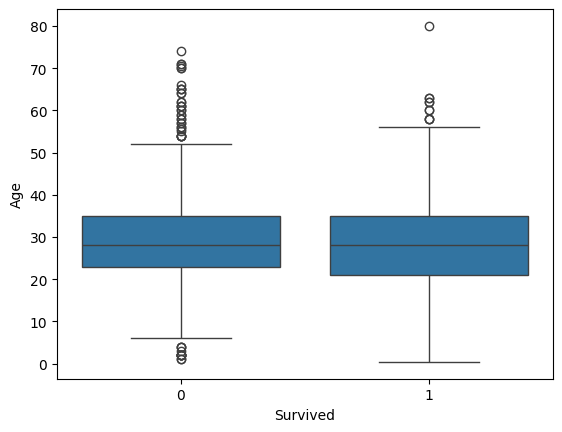

In [48]:
sns.boxplot(data=df,x='Survived',y="Age")

#
There isn't a huge difference in the median age between survivors and non-survivors, but survivors show a slightly wider spread toward younger ages.

#Survived vs Embarked

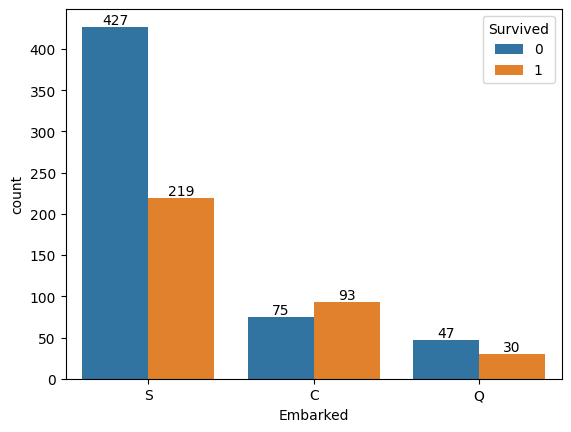

In [49]:
ax=sns.countplot(data=df,x='Embarked',hue='Survived')
for cont in ax.containers:
  ax.bar_label(cont)

#
Passengers who boarded from Cherbourg (C) had the highest survival rate (~55%), despite Southampton (S) having the highest number of total survivors. This is because S carried more 3rd class passengers, who had lower survival rates overall.

#Survived vs Fare

<Axes: xlabel='Survived', ylabel='Fare'>

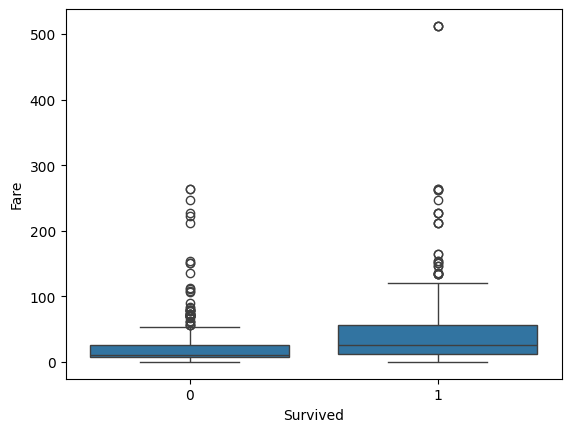

In [50]:
sns.boxplot(data=df,x='Survived',y='Fare')

#
Survivors generally paid higher fares compared to non-survivors, reinforcing that wealthier passengers (who could afford higher fares/better class) had better survival chances.

#Survived vs **Family**

<Axes: xlabel='Survived', ylabel='family'>

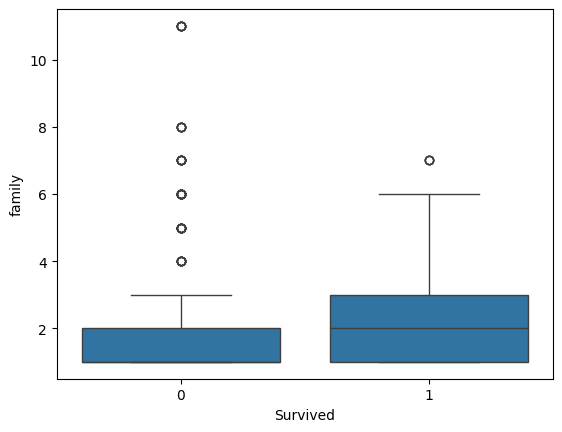

In [51]:
df['family']=df['SibSp']+df['Parch']+1
sns.boxplot(data=df,x="Survived",y="family")

#
Passengers with a moderate family size (2-4 members) had better survival chances compared to those traveling completely alone or with very large families.

#Pivot Table

In [52]:
df.pivot_table(index='Survived',values=['Age','SibSp','Parch',"Fare"])

,Age,Fare,Parch,SibSp
Survived,,,,
0,30.028233,22.117887,0.329690,0.553734
1,28.291433,48.395408,0.464912,0.473684


#Percentage

In [53]:
df.groupby("Sex")['Survived'].mean()

,Survived
Sex,
female,0.742038
male,0.188908


In [54]:
df.groupby('Pclass')['Survived'].mean()

,Survived
Pclass,
1,0.629630
2,0.472826
3,0.242363


In [55]:
df.groupby("Embarked")["Survived"].mean()

,Survived
Embarked,
C,0.553571
Q,0.389610
S,0.339009


#Final Conclusion:

This analysis shows that survival on the Titanic was strongly influenced by gender, class, fare, and family size. Females, 1st class passengers, and those with moderate family sizes had significantly higher survival rates, while 3rd class male passengers traveling alone had the lowest chances of survival.